In [11]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [12]:
demo  = pd.read_sas('P_DEMO.XPT',  format='xport', encoding='utf-8')
bmx   = pd.read_sas('P_BMX.XPT',   format='xport', encoding='utf-8')
bpxo  = pd.read_sas('P_BPXO.xpt',  format='xport', encoding='utf-8')
tchol = pd.read_sas('P_TCHOL.xpt', format='xport', encoding='utf-8')
diq   = pd.read_sas('P_DIQ.xpt',   format='xport', encoding='utf-8')
cdq   = pd.read_sas('P_CDQ.xpt',   format='xport', encoding='utf-8')

In [13]:
# Merge — CDQ as base (adults 40+ only)
df = (cdq[['SEQN','CDQ001','CDQ010']]
      .merge(demo[['SEQN','RIDAGEYR','RIAGENDR','RIDRETH3','INDFMPIR','WTMECPRP','SDMVPSU','SDMVSTRA']], on='SEQN', how='left')
      .merge(bmx[['SEQN','BMXBMI','BMXWAIST']], on='SEQN', how='left')
      .merge(bpxo[['SEQN','BPXOSY1','BPXODI1']], on='SEQN', how='left')
      .merge(tchol[['SEQN','LBXTC']], on='SEQN', how='left')
      .merge(diq[['SEQN','DIQ010']], on='SEQN', how='left')
     )

print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nTarget (CDQ001):\n{df['CDQ001'].value_counts()}")

Shape: (6433, 16)

Missing values:
SEQN           0
CDQ001         0
CDQ010         0
RIDAGEYR       0
RIAGENDR       0
RIDRETH3       0
INDFMPIR     988
WTMECPRP       0
SDMVPSU        0
SDMVSTRA       0
BMXBMI       622
BMXWAIST     855
BPXOSY1     1089
BPXODI1     1089
LBXTC        901
DIQ010         0
dtype: int64

Target (CDQ001):
CDQ001
2.0    4533
1.0    1896
9.0       4
Name: count, dtype: int64


In [14]:
# ── Step 2: Clean & Feature Engineering ──────────────────────────────────────

# Drop the 4 "don't know" responses on target
df = df[df['CDQ001'] != 9.0].copy()

# Binary target: 1 = chest pain (CVD symptom), 0 = no
df['cvd_symptom'] = (df['CDQ001'] == 1.0).astype(int)

# Recode sex: 1=Male, 0=Female
df['male'] = (df['RIAGENDR'] == 1.0).astype(int)

# Recode diabetes: 1=Diagnosed, 0=No/Borderline
df['diabetes'] = (df['DIQ010'] == 1.0).astype(int)

# Recode race/ethnicity (RIDRETH3)
# 1=Mexican American, 2=Other Hispanic, 3=Non-Hispanic White,
# 4=Non-Hispanic Black, 6=Non-Hispanic Asian, 7=Other/Multiracial
race_map = {1.0:'Hispanic', 2.0:'Hispanic', 3.0:'NH_White',
            4.0:'NH_Black', 6.0:'NH_Asian', 7.0:'Other'}
df['race_eth'] = df['RIDRETH3'].map(race_map)
df = pd.get_dummies(df, columns=['race_eth'], drop_first=True)

# Rename for clarity
df.rename(columns={
    'RIDAGEYR': 'age',
    'BMXBMI':   'bmi',
    'BMXWAIST': 'waist_cm',
    'BPXOSY1':  'sbp',      # systolic BP
    'BPXODI1':  'dbp',      # diastolic BP
    'LBXTC':    'total_chol',
    'INDFMPIR': 'income_pir',
}, inplace=True)

# Median imputation for continuous vars (domain-standard for NHANES)
for col in ['bmi','waist_cm','sbp','dbp','total_chol','income_pir']:
    df[col] = df[col].fillna(df[col].median())

# Feature: hypertension flag (SBP >= 130 per ACC/AHA 2017 guidelines)
df['hypertension'] = (df['sbp'] >= 130).astype(int)

# Feature: obese flag (BMI >= 30)
df['obese'] = (df['bmi'] >= 30).astype(int)

# Feature: high cholesterol flag (>= 200 mg/dL)
df['high_chol'] = (df['total_chol'] >= 200).astype(int)

# Drop raw columns we no longer need
df.drop(columns=['CDQ001','CDQ010','RIAGENDR','RIDRETH3','DIQ010'], inplace=True)

print(f"Final dataset shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['cvd_symptom'].value_counts())
print(f"\nPositive rate: {df['cvd_symptom'].mean():.1%}")
print(f"\nFeature columns:\n{[c for c in df.columns if c not in ['SEQN','WTMECPRP','SDMVPSU','SDMVSTRA']]}")
print(f"\nAny remaining nulls:\n{df.isnull().sum()[df.isnull().sum()>0]}")

Final dataset shape: (6429, 21)

Target distribution:
cvd_symptom
0    4533
1    1896
Name: count, dtype: int64

Positive rate: 29.5%

Feature columns:
['age', 'income_pir', 'bmi', 'waist_cm', 'sbp', 'dbp', 'total_chol', 'cvd_symptom', 'male', 'diabetes', 'race_eth_NH_Asian', 'race_eth_NH_Black', 'race_eth_NH_White', 'race_eth_Other', 'hypertension', 'obese', 'high_chol']

Any remaining nulls:
Series([], dtype: int64)


Features (16): ['age', 'income_pir', 'bmi', 'waist_cm', 'sbp', 'dbp', 'total_chol', 'male', 'diabetes', 'race_eth_NH_Asian', 'race_eth_NH_Black', 'race_eth_NH_White', 'race_eth_Other', 'hypertension', 'obese', 'high_chol']

Train: (5143, 16), Test: (1286, 16)

=== Model Results ===

Logistic Regression
  CV AUC:   0.6063 ± 0.0169
  Test AUC: 0.6331

Random Forest
  CV AUC:   0.6070 ± 0.0226
  Test AUC: 0.6385

XGBoost
  CV AUC:   0.5871 ± 0.0171
  Test AUC: 0.6213

MLP Neural Network
  CV AUC:   0.5388 ± 0.0088
  Test AUC: 0.5316


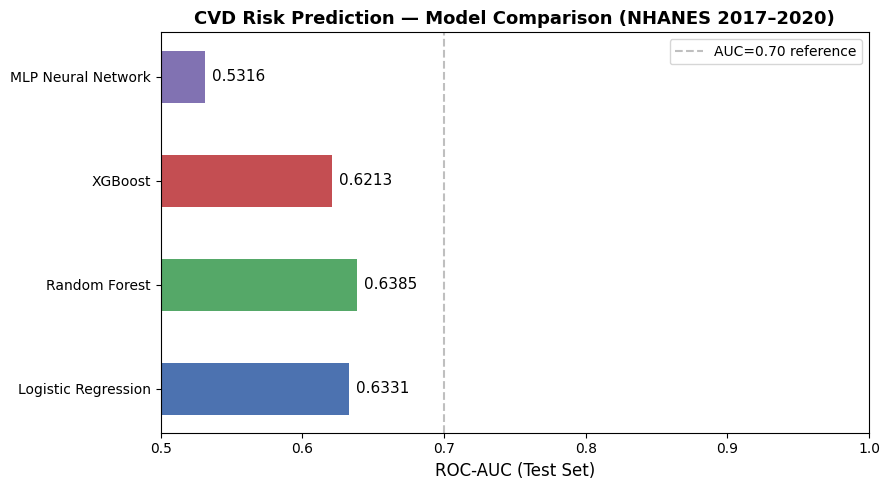


Chart saved.


In [15]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# ── Define features and target ────────────────────────────────────────────────
drop_cols = ['SEQN','WTMECPRP','SDMVPSU','SDMVSTRA','cvd_symptom']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df['cvd_symptom']

print(f"Features ({len(feature_cols)}): {feature_cols}")

# ── Train/test split (stratified) ────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

# ── Define models ─────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1
    ),
    'MLP Neural Network': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42))
    ])
}

# ── Train, evaluate, collect AUCs ────────────────────────────────────────────
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n=== Model Results ===")
for name, model in models.items():
    # 5-fold CV AUC
    cv_aucs = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    # Fit on full train, score on test
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:,1]
    test_auc = roc_auc_score(y_test, y_prob)
    results[name] = {'cv_auc': cv_aucs.mean(), 'cv_std': cv_aucs.std(), 'test_auc': test_auc}
    print(f"\n{name}")
    print(f"  CV AUC:   {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}")
    print(f"  Test AUC: {test_auc:.4f}")

# ── Summary bar chart ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
names = list(results.keys())
test_aucs = [results[n]['test_auc'] for n in names]
colors = ['#4C72B0','#55A868','#C44E52','#8172B2']
bars = ax.barh(names, test_aucs, color=colors, height=0.5)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel('ROC-AUC (Test Set)', fontsize=12)
ax.set_title('CVD Risk Prediction — Model Comparison (NHANES 2017–2020)', fontsize=13, fontweight='bold')
for bar, auc in zip(bars, test_aucs):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{auc:.4f}', va='center', fontsize=11)
ax.axvline(0.7, color='gray', linestyle='--', alpha=0.5, label='AUC=0.70 reference')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved.")

In [16]:
# ── Step 3: Feature Enhancement + Tuned XGBoost ──────────────────────────────

# Add CDQ010 (shortness of breath) back — strong correlated symptom
df2 = df.copy()

# Re-load CDQ010 from original cdq file
cdq_extra = cdq[['SEQN','CDQ010']].copy()
cdq_extra['sob'] = (cdq_extra['CDQ010'] == 1.0).astype(int)  # 1=Yes shortness of breath
df2 = df2.merge(cdq_extra[['SEQN','sob']], on='SEQN', how='left')
df2['sob'] = df2['sob'].fillna(0)

# Interaction features
df2['age_x_male']     = df2['age'] * df2['male']
df2['age_x_diabetes'] = df2['age'] * df2['diabetes']
df2['sbp_x_chol']     = df2['sbp'] * df2['total_chol']
df2['bmi_x_diabetes'] = df2['bmi'] * df2['diabetes']

# Pulse pressure (SBP - DBP) — clinical CVD marker
df2['pulse_pressure'] = df2['sbp'] - df2['dbp']

print("New feature set:")
drop_cols2 = ['SEQN','WTMECPRP','SDMVPSU','SDMVSTRA','cvd_symptom']
feature_cols2 = [c for c in df2.columns if c not in drop_cols2]
print(feature_cols2)

X2 = df2[feature_cols2]
y2 = df2['cvd_symptom']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# ── Tuned XGBoost ─────────────────────────────────────────────────────────────
xgb_tuned = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    scale_pos_weight=(y2_train==0).sum()/(y2_train==1).sum(),
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# ── Re-run all models on enhanced features ────────────────────────────────────
models2 = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=10,
        random_state=42, n_jobs=-1
    ),
    'XGBoost (tuned)': xgb_tuned,
    'MLP Neural Network': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(hidden_layer_sizes=(128,64,32), max_iter=500, random_state=42))
    ])
}

results2 = {}
print("\n=== Enhanced Model Results ===")
for name, model in models2.items():
    cv_aucs = cross_val_score(model, X2_train, y2_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    model.fit(X2_train, y2_train)
    y_prob = model.predict_proba(X2_test)[:,1]
    test_auc = roc_auc_score(y2_test, y_prob)
    results2[name] = {'cv_auc': cv_aucs.mean(), 'cv_std': cv_aucs.std(), 'test_auc': test_auc}
    print(f"\n{name}")
    print(f"  CV AUC:   {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}")
    print(f"  Test AUC: {test_auc:.4f}")

New feature set:
['age', 'income_pir', 'bmi', 'waist_cm', 'sbp', 'dbp', 'total_chol', 'male', 'diabetes', 'race_eth_NH_Asian', 'race_eth_NH_Black', 'race_eth_NH_White', 'race_eth_Other', 'hypertension', 'obese', 'high_chol', 'sob', 'age_x_male', 'age_x_diabetes', 'sbp_x_chol', 'bmi_x_diabetes', 'pulse_pressure']

=== Enhanced Model Results ===

Logistic Regression
  CV AUC:   0.6968 ± 0.0210
  Test AUC: 0.6879

Random Forest
  CV AUC:   0.7001 ± 0.0194
  Test AUC: 0.6935

XGBoost (tuned)
  CV AUC:   0.6865 ± 0.0226
  Test AUC: 0.6747

MLP Neural Network
  CV AUC:   0.5977 ± 0.0111
  Test AUC: 0.5831


shap_vals type: <class 'numpy.ndarray'>
shap_vals shape: (1286, 22, 2)
sv shape: (1286, 22)
X2_test shape: (1286, 22)


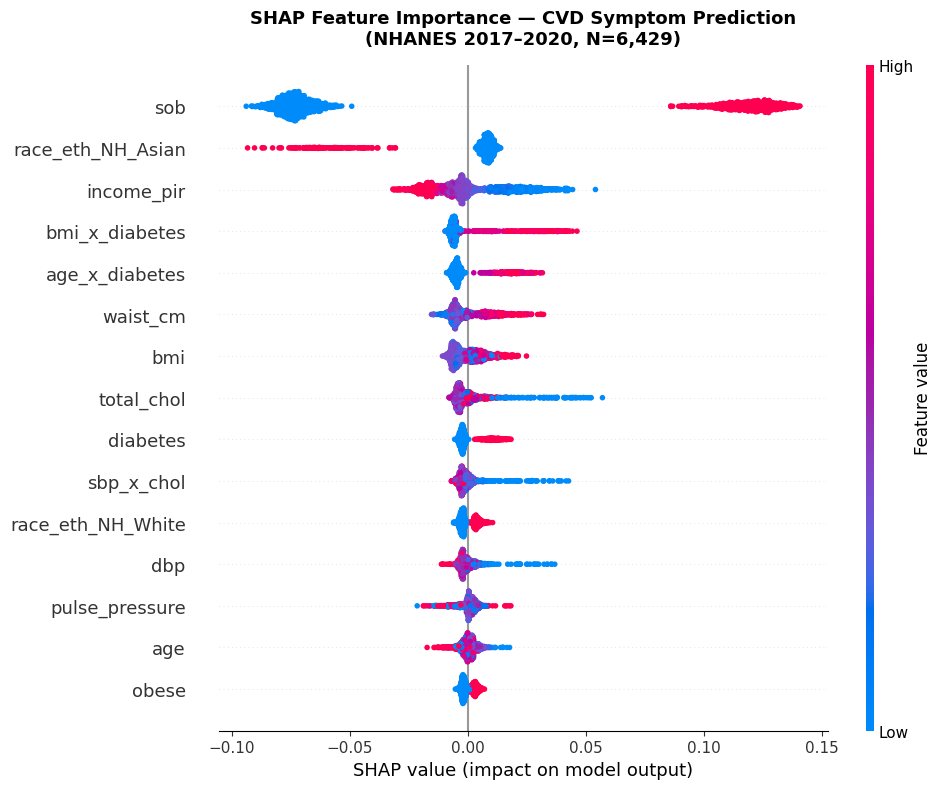

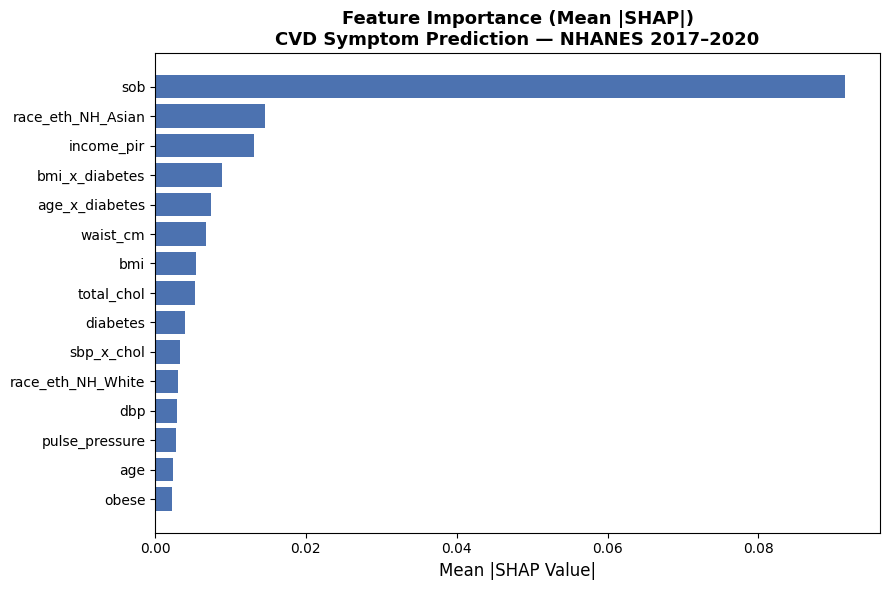


Top features by mean |SHAP|:
          Feature  Mean |SHAP|
              sob     0.091561
race_eth_NH_Asian     0.014516
       income_pir     0.013080
   bmi_x_diabetes     0.008863
   age_x_diabetes     0.007449
         waist_cm     0.006743
              bmi     0.005458
       total_chol     0.005306
         diabetes     0.003961
       sbp_x_chol     0.003296
race_eth_NH_White     0.003039
              dbp     0.002906
   pulse_pressure     0.002710
              age     0.002360
            obese     0.002272


In [17]:
import shap
import matplotlib.pyplot as plt
import numpy as np

rf_best = models2['Random Forest']

explainer = shap.TreeExplainer(rf_best)
shap_vals = explainer.shap_values(X2_test)

# shap_vals shape check
print(f"shap_vals type: {type(shap_vals)}")
print(f"shap_vals shape: {np.array(shap_vals).shape}")

# For RF binary: shap_vals is [n_samples, n_features, 2] OR list of 2 arrays
# Extract class=1 values
if isinstance(shap_vals, list):
    sv = shap_vals[1]           # list format
elif np.array(shap_vals).ndim == 3:
    sv = shap_vals[:, :, 1]     # 3D array format
else:
    sv = shap_vals

print(f"sv shape: {sv.shape}")
print(f"X2_test shape: {X2_test.shape}")

# ── Beeswarm plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    sv, X2_test,
    plot_type='dot',
    max_display=15,
    show=False,
    plot_size=(10, 8)
)
plt.title('SHAP Feature Importance — CVD Symptom Prediction\n(NHANES 2017–2020, N=6,429)',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 6))
mean_shap = pd.DataFrame({
    'Feature': X2_test.columns,
    'Mean |SHAP|': np.abs(sv).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=True).tail(15)

ax2.barh(mean_shap['Feature'], mean_shap['Mean |SHAP|'], color='#4C72B0')
ax2.set_xlabel('Mean |SHAP Value|', fontsize=12)
ax2.set_title('Feature Importance (Mean |SHAP|)\nCVD Symptom Prediction — NHANES 2017–2020',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Top features table ────────────────────────────────────────────────────────
top = mean_shap.sort_values('Mean |SHAP|', ascending=False)
print("\nTop features by mean |SHAP|:")
print(top.to_string(index=False))

In [18]:
# ── Final summary for documentation ──────────────────────────────────────────
print("=" * 55)
print("PROJECT SUMMARY — NHANES CVD Risk Stratification")
print("=" * 55)
print(f"Dataset:        NHANES 2017–March 2020 Pre-Pandemic")
print(f"Files merged:   6 XPT files across 4 NHANES components")
print(f"Final N:        {len(df2):,} adults aged 40+")
print(f"Features:       {len(feature_cols2)} (incl. 4 engineered interaction terms)")
print(f"Target:         CVD symptom (chest pain on exertion)")
print(f"Positive rate:  {df2['cvd_symptom'].mean():.1%}")
print()
print("Model Performance (Test ROC-AUC):")
for name, r in results2.items():
    print(f"  {name:<25} {r['test_auc']:.4f}")
print()
best_model = max(results2, key=lambda x: results2[x]['test_auc'])
best_auc = results2[best_model]['test_auc']
print(f"Best model:     {best_model} (AUC {best_auc:.4f})")
print()
print("Top SHAP predictors:")
for _, row in top.head(5).iterrows():
    print(f"  {row['Feature']:<25} {row['Mean |SHAP|']:.4f}")
print()
print("Output files:   model_comparison.png, shap_beeswarm.png, shap_bar.png")

PROJECT SUMMARY — NHANES CVD Risk Stratification
Dataset:        NHANES 2017–March 2020 Pre-Pandemic
Files merged:   6 XPT files across 4 NHANES components
Final N:        6,429 adults aged 40+
Features:       22 (incl. 4 engineered interaction terms)
Target:         CVD symptom (chest pain on exertion)
Positive rate:  29.5%

Model Performance (Test ROC-AUC):
  Logistic Regression       0.6879
  Random Forest             0.6935
  XGBoost (tuned)           0.6747
  MLP Neural Network        0.5831

Best model:     Random Forest (AUC 0.6935)

Top SHAP predictors:
  sob                       0.0916
  race_eth_NH_Asian         0.0145
  income_pir                0.0131
  bmi_x_diabetes            0.0089
  age_x_diabetes            0.0074

Output files:   model_comparison.png, shap_beeswarm.png, shap_bar.png
